# JET Global Sensitivity Analysis with SALib (Sobol Indices)

This notebook performs a Global Sensitivity Analysis (GSA) of the JET ensemble using ECOSTRESS Collection 2 Cal-Val data and **Sobol indices** via the `SALib` package. It computes first-order ($S_1$) and total-order ($S_T$) indices to rigorously quantify the fractional variance each input variable contributes to model outputs like latent heat flux and evapotranspiration.[cite: 1]

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import SALib modules for Global Sensitivity Analysis
from SALib.sample import saltelli
from SALib.analyze import sobol
from sklearn.metrics import r2_score, mean_squared_error

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from contextlib import redirect_stdout, redirect_stderr
from SALib.sample import saltelli
from SALib.analyze import sobol

# Custom JET modules
from JET3 import process_JET_table, load_ECOv002_calval_JET_inputs

# Set Seaborn style for prettier plots globally
sns.set_theme(style="whitegrid", palette="muted")

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger().setLevel(logging.CRITICAL)

This function runs the accuracy validation.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

def plot_insitu_accuracy(df, variable_name, insitu_variable_name=None, color=None, model_name=None, cmap="viridis", legend_loc=None, annotate_loc=None):
    """
    Generates a scatter plot comparing a single in-situ variable to its model equivalent,
    with automatic or manual placement of legends and annotations based on data trends.
    """
    try:
        # Use provided insitu_variable_name, otherwise default to f"insitu_{variable_name}"
        insitu_variable = insitu_variable_name if insitu_variable_name is not None else f"insitu_{variable_name}"
        model_prefix = f"{model_name} " if model_name else ""
        
        x_variable = insitu_variable
        y_variable = variable_name

        # Check if required columns exist
        required_cols = [x_variable, y_variable]
        if color and color in df.columns:
            required_cols.append(color)
            
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise KeyError(f"Missing required columns in dataframe: {missing_cols}")

        # Filter out rows with NaN values in relevant variables
        valid_data = df[required_cols].dropna()
        
        if valid_data.empty:
            print(f"No valid data remaining after dropping NaNs for {variable_name}. Skipping.")
            return

        # Initialize figure
        plt.figure(figsize=(8, 6))
        
        sc = plt.scatter(
            x=valid_data[x_variable],
            y=valid_data[y_variable],
            c=valid_data[color] if color is not None else None,
            cmap=cmap,
            s=15,
            edgecolor="none",
            alpha=0.8
        )

        # Calculate OLS regression line coefficients
        slope, intercept = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)

        # Add 1-to-1 line
        plt.axline((0, 0), slope=1, color='gray', linestyle='-', linewidth=1.5, label='1:1 Line')

        # Add OLS regression line
        plt.axline((0, intercept), slope=slope, color='#d62728', linestyle='--', linewidth=2, label='OLS Fit')

        # Calculate Absolute Accuracy Metrics (1:1 Comparison)
        y_true = valid_data[x_variable]
        y_pred = valid_data[y_variable]
        
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # --- Auto-positioning Logic ---
        # If slope is positive: legend top-left, metrics bottom-right
        # If slope is negative: legend top-right, metrics bottom-left
        if legend_loc is None:
            legend_loc = 'upper left' if slope >= 0 else 'upper right'
            
        if annotate_loc is None:
            annotate_loc = 'lower right' if slope >= 0 else 'lower left'

        # Map string locations to plotting coordinates for the annotation box
        annotation_positions = {
            'upper left':  {'xy': (0.05, 0.95), 'ha': 'left', 'va': 'top'},
            'upper right': {'xy': (0.95, 0.95), 'ha': 'right', 'va': 'top'},
            'lower left':  {'xy': (0.05, 0.05), 'ha': 'left', 'va': 'bottom'},
            'lower right': {'xy': (0.95, 0.05), 'ha': 'right', 'va': 'bottom'}
        }
        
        # Get coordinates, fallback to lower right if an unrecognized string is passed manually
        ann_kwargs = annotation_positions.get(annotate_loc, annotation_positions['lower right'])

        # Annotate R-squared and RMSE on plot
        plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.2f}",
                    xy=ann_kwargs['xy'], xycoords='axes fraction',
                    ha=ann_kwargs['ha'], va=ann_kwargs['va'],
                    fontsize=11,
                    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='lightgray', alpha=0.9))

        # Formatting
        display_insitu = insitu_variable_name if insitu_variable_name is not None else f"In-Situ {variable_name}"
        
        plt.xlabel(display_insitu, fontsize=11, weight='bold')
        plt.ylabel(f"{model_prefix}{variable_name}", fontsize=11, weight='bold')
        plt.title(f"Accuracy Comparison\n{display_insitu} vs {model_prefix}{variable_name}", fontsize=14, weight='bold')
        
        if color:
            plt.colorbar(sc, label=f"{color} Value")
            
        plt.legend(loc=legend_loc, frameon=True)
        sns.despine(left=True, bottom=True)
        
        plt.tight_layout()
        plt.show()
        plt.close() 
        
    except Exception as e:
        # Fallback in case it fails before insitu_variable is assigned
        err_var = locals().get('insitu_variable', variable_name)
        print(f"Error processing {err_var}: {e}")

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

def plot_insitu_accuracy(df, variable_name, insitu_variable_name=None, color=None, model_name=None, cmap="viridis", legend_loc=None, annotate_loc=None):
    """
    Generates a scatter plot comparing a single in-situ variable to its model equivalent,
    with automatic or manual placement of legends and annotations based on data trends.
    The colormap is scaled between the 5th and 95th percentiles of the color variable.
    """
    try:
        # Use provided insitu_variable_name, otherwise default to f"insitu_{variable_name}"
        insitu_variable = insitu_variable_name if insitu_variable_name is not None else f"insitu_{variable_name}"
        model_prefix = f"{model_name} " if model_name else ""
        
        x_variable = insitu_variable
        y_variable = variable_name

        # Check if required columns exist
        required_cols = [x_variable, y_variable]
        if color and color in df.columns:
            required_cols.append(color)
            
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise KeyError(f"Missing required columns in dataframe: {missing_cols}")

        # Filter out rows with NaN values in relevant variables
        valid_data = df[required_cols].dropna()
        
        if valid_data.empty:
            print(f"No valid data remaining after dropping NaNs for {variable_name}. Skipping.")
            return

        # Initialize figure
        plt.figure(figsize=(8, 6))
        
        # Calculate 5th and 95th percentiles for the colormap limits
        vmin, vmax = None, None
        if color is not None:
            vmin = np.percentile(valid_data[color], 5)
            vmax = np.percentile(valid_data[color], 95)
        
        sc = plt.scatter(
            x=valid_data[x_variable],
            y=valid_data[y_variable],
            c=valid_data[color] if color is not None else None,
            cmap=cmap,
            vmin=vmin,  # Apply 5th percentile lower bound
            vmax=vmax,  # Apply 95th percentile upper bound
            s=15,
            edgecolor="none",
            alpha=0.8
        )

        # Calculate OLS regression line coefficients
        slope, intercept = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)

        # Add 1-to-1 line
        plt.axline((0, 0), slope=1, color='gray', linestyle='-', linewidth=1.5, label='1:1 Line')

        # Add OLS regression line
        plt.axline((0, intercept), slope=slope, color='#d62728', linestyle='--', linewidth=2, label='OLS Fit')

        # Calculate Absolute Accuracy Metrics (1:1 Comparison)
        y_true = valid_data[x_variable]
        y_pred = valid_data[y_variable]
        
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # --- Auto-positioning Logic ---
        # If slope is positive: legend top-left, metrics bottom-right
        # If slope is negative: legend top-right, metrics bottom-left
        if legend_loc is None:
            legend_loc = 'upper left' if slope >= 0 else 'upper right'
            
        if annotate_loc is None:
            annotate_loc = 'lower right' if slope >= 0 else 'lower left'

        # Map string locations to plotting coordinates for the annotation box
        annotation_positions = {
            'upper left':  {'xy': (0.05, 0.95), 'ha': 'left', 'va': 'top'},
            'upper right': {'xy': (0.95, 0.95), 'ha': 'right', 'va': 'top'},
            'lower left':  {'xy': (0.05, 0.05), 'ha': 'left', 'va': 'bottom'},
            'lower right': {'xy': (0.95, 0.05), 'ha': 'right', 'va': 'bottom'}
        }
        
        # Get coordinates, fallback to lower right if an unrecognized string is passed manually
        ann_kwargs = annotation_positions.get(annotate_loc, annotation_positions['lower right'])

        # Annotate R-squared and RMSE on plot
        plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.2f}",
                    xy=ann_kwargs['xy'], xycoords='axes fraction',
                    ha=ann_kwargs['ha'], va=ann_kwargs['va'],
                    fontsize=11,
                    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='lightgray', alpha=0.9))

        # Formatting
        display_insitu = insitu_variable_name if insitu_variable_name is not None else f"In-Situ {variable_name}"
        
        plt.xlabel(display_insitu, fontsize=11, weight='bold')
        plt.ylabel(f"{model_prefix}{variable_name}", fontsize=11, weight='bold')
        plt.title(f"Accuracy Comparison\n{display_insitu} vs {model_prefix}{variable_name}", fontsize=14, weight='bold')
        
        if color:
            plt.colorbar(sc, label=f"{color} Value")
            
        plt.legend(loc=legend_loc, frameon=True)
        sns.despine(left=True, bottom=True)
        
        plt.tight_layout()
        plt.show()
        plt.close() 
        
    except Exception as e:
        # Fallback in case it fails before insitu_variable is assigned
        err_var = locals().get('insitu_variable', variable_name)
        print(f"Error processing {err_var}: {e}")

This function runs the SOBOL index sensitivity analysis.

In [4]:
import os
import contextlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from SALib.sample import saltelli
from SALib.analyze import sobol

def SOBOL_sensitivity_analysis(input_df, input_variables, target_output, forward_process, N=256, theme_name="whitegrid", palette_name="viridis"):
    """
    Generates Saltelli samples from the bounds of the input table, runs the 
    forward model via a callback parameter (with console output suppressed), 
    and computes/plots first-order (S1) and total-order (ST) Sobol indices.
    The plot is sorted in descending order by the total-order index (ST).
    """
    # 1. Clean the input table and dynamically define problem bounds
    input_df_clean = input_df.dropna(subset=[var for var in input_variables if var in input_df.columns])
    
    problem = {
        'num_vars': len(input_variables),
        'names': input_variables,
        'bounds': [
            [input_df_clean[var].min(), input_df_clean[var].max()] 
            for var in input_variables
        ]
    }
    
    # 2. Generate Saltelli samples 
    # Note: N should ideally be a power of 2. The total number of samples will be N * (2D + 2)
    param_values = saltelli.sample(problem, N, calc_second_order=True)
    
    # 3. Broadcast a static base row to match the Saltelli matrix size
    # This ensures any required columns NOT in input_variables still exist for the forward_process
    base_row = input_df_clean.iloc[[0]].copy()
    samples_df = pd.concat([base_row] * len(param_values), ignore_index=True)
    
    # Overwrite the input variables with the generated samples
    for i, var in enumerate(input_variables):
        samples_df[var] = param_values[:, i]
        
    # 4. Execute the forward run and suppress its console output
    print(f"Executing forward process for {len(samples_df)} generated samples (console output hidden)...")
    
    with open(os.devnull, 'w') as fnull:
        with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
            processed_samples = forward_process(samples_df)
            
    print("Forward process complete.")
    
    # 5. Extract the target output values and check for NaNs
    Y = processed_samples[target_output].values
    if np.isnan(Y).any():
        print("Warning: The forward process returned NaN values. Forward-filling to prevent SALib crash.")
        Y = pd.Series(Y).ffill().bfill().values
    
    # 6. Calculate Sobol indices
    Si = sobol.analyze(problem, Y, calc_second_order=True)
    
    # --- Sort the variables based on ST descending ---
    sort_indices = np.argsort(Si['ST'])[::-1]
    sorted_vars = [input_variables[i] for i in sort_indices]
    sorted_S1 = Si['S1'][sort_indices]
    sorted_ST = Si['ST'][sort_indices]
    
    # 7. Visualize First-Order and Total-Order Indices
    sns.set_theme(style=theme_name)
    colors = sns.color_palette(palette_name)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    x = np.arange(len(sorted_vars))
    width = 0.35
    
    ax.bar(x - width/2, sorted_S1, width, label='S1 (First-order: Direct Variance)', color=colors[0], edgecolor="white", linewidth=1)
    ax.bar(x + width/2, sorted_ST, width, label='ST (Total-order: Includes Interactions)', color=colors[1], edgecolor="white", linewidth=1)
    
    ax.set_ylabel('Sobol Index', fontsize=12, weight='bold')
    ax.set_title(f'Sobol Sensitivity Indices for {target_output}', fontsize=15, weight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_vars, rotation=45, ha='right', fontsize=11)
    ax.legend(frameon=True, facecolor='white', edgecolor='lightgray')
    
    # Remove top and right borders for a cleaner look
    sns.despine(left=True)
    ax.grid(axis='y', linestyle='-', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return Si

Load the cal/val dataset.

In [5]:
# Load baseline data first
input_variables = [
    "ST_C",
    "NDVI",
    "albedo",
    "Ta_C",
    "RH",
    "AOT",
    "COT",
    "vapor_gccm",
    "ozone_cm",
    "elevation_m",
    "canopy_height_meters"
]

output_variables = [
    "Rn_Wm2",
    "ET_daylight_kg",
    "GPP_inst_g_m2_s"
]

# Per-variable physical bounds to keep perturbations realistic
input_min = {
    "ST_C": 0.0,
    "NDVI": 0.05,
    "albedo": 0.0,
    "Ta_C": 0.0,
    "RH": 0.0,
    "AOT": 0.0,
    "COT": 0.0,
    "vapor_gccm": 0.0,
    "ozone_cm": 0.0,
    "elevation_m": 0.0,
    "canopy_height_meters": 0.0,
}

input_max = {
    "ST_C": 50.0,
    "NDVI": 1,
    "albedo": 1,
}

input_df = load_ECOv002_calval_JET_inputs()

# Apply lower and upper bounds from configuration dictionaries
mask = pd.Series(True, index=input_df.index)
for var, min_val in input_min.items():
    if var in input_df.columns:
        mask &= input_df[var] >= min_val
for var, max_val in input_max.items():
    if var in input_df.columns:
        mask &= input_df[var] <= max_val

input_df = input_df[mask]
input_df = input_df.dropna()
input_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,CL,Tmin_open,Tmin_closed,VPD_open,VPD_closed,Tmin_C,Topt_C,fAPARmax,field_capacity,wilting_point
15,15,US-xAB,ENF,Csb,141.635670,168.24043,402.81810,159.71700,139.016083,107.183200,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
17,17,US-xAB,ENF,Csb,1.881266,163.94730,301.40400,179.13661,131.273636,106.525215,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
18,18,US-xAB,ENF,Csb,3.135606,246.87700,614.51480,405.50497,366.056641,222.890230,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
19,19,US-xAB,ENF,Csb,311.482820,290.73126,672.27510,478.82382,439.821228,153.787670,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
20,20,US-xAB,ENF,Csb,51.920338,95.28810,116.67136,73.20884,232.693512,24.038680,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,992,US-xML,DBF,Dfb,417.831120,706.93066,523.92740,310.69684,356.174072,148.624050,...,0.0065,11.39,-8.0,650.0,3500.0,27.538052,2.66,0.5404,0.34,0.14
994,994,US-xML,DBF,Dfb,161.558200,306.15277,420.44678,206.48576,237.659103,98.727560,...,0.0065,11.39,-8.0,650.0,3500.0,27.538052,2.66,0.5404,0.34,0.14
1001,1001,US-UiB,CRO,Dfa,93.876100,251.38747,238.71077,198.90399,106.316444,67.694800,...,0.0070,12.02,-8.0,650.0,4500.0,9.637029,2.58,0.4060,0.32,0.14
1020,1020,US-ARM,CRO,Cfa,80.255005,0.00000,180.10085,211.28325,164.581390,84.672410,...,0.0070,12.02,-8.0,650.0,4500.0,9.637029,8.48,0.4017,0.29,0.12


Run the cal/val dataset through the forward process.

In [6]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    processed_df = process_JET_table(input_df)
    
processed_df

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
<class 'numpy.ndarray'>
float32


/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/pytho

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,G_PMJPL_Wm2,G_Wm2,LE_instantaneous_Wm2,LE_Wm2,H_Wm2,ET_daylight_kg,ET_uncertainty,GPP_inst_g_m2_s,ET_canopy_inst_kg_m2_s,WUE
15,15,US-xAB,ENF,Csb,141.635670,168.24043,402.81810,159.71700,139.016083,107.183200,...,24.219544,24.219544,203.764376,203.764376,248.713696,2.900053,0.510811,0.000151,0.000058,2.606544
17,17,US-xAB,ENF,Csb,1.881266,163.94730,301.40400,179.13661,131.273636,106.525215,...,13.772918,13.772918,163.144742,163.144742,194.438550,2.854526,1.085331,0.000108,0.000034,3.174119
18,18,US-xAB,ENF,Csb,3.135606,246.87700,614.51480,405.50497,366.056641,222.890230,...,33.327171,33.327171,342.565013,342.565013,348.501129,4.442026,0.971980,0.000291,0.000122,2.390822
19,19,US-xAB,ENF,Csb,311.482820,290.73126,672.27510,478.82382,439.821228,153.787670,...,42.878466,42.878466,403.011097,403.011097,366.186555,4.947329,1.401781,0.000294,0.000211,1.388074
20,20,US-xAB,ENF,Csb,51.920338,95.28810,116.67136,73.20884,232.693512,24.038680,...,2.903705,2.903705,112.556235,112.556235,52.720986,2.991218,0.730132,0.000095,0.000015,6.238326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,992,US-xML,DBF,Dfb,417.831120,706.93066,523.92740,310.69684,356.174072,148.624050,...,29.623891,29.623891,397.732265,397.732265,216.894638,3.642505,1.045928,0.000233,0.000137,1.697664
994,994,US-xML,DBF,Dfb,161.558200,306.15277,420.44678,206.48576,237.659103,98.727560,...,21.577865,21.577865,285.469147,285.469147,216.864039,2.883329,1.141584,0.000138,0.000101,1.357232
1001,1001,US-UiB,CRO,Dfa,93.876100,251.38747,238.71077,198.90399,106.316444,67.694800,...,77.061858,77.061858,105.892160,105.892160,409.322436,1.323772,1.130343,0.000053,0.000016,3.203371
1020,1020,US-ARM,CRO,Cfa,80.255005,0.00000,180.10085,211.28325,164.581390,84.672410,...,69.968594,69.968594,119.836612,119.836612,285.958690,1.413853,1.294936,0.000048,0.000031,1.555148


In [7]:
[column for column in processed_df.columns if "ET" in column]

['ETinst',
 'ETinstUncertainty',
 'PET',
 'NETRAD_filt',
 'JET',
 'insitu_ET_daylight_kg',
 'ET_daylight_BESS_kg',
 'ET_daylight_STIC_kg',
 'ET_daylight_PTJPLSM_kg',
 'PET_instantaneous_PTJPLSM_Wm2',
 'ET_daylight_PMJPL_kg',
 'ET_daylight_kg',
 'ET_uncertainty',
 'ET_canopy_inst_kg_m2_s']

Air Temperature Accuracy

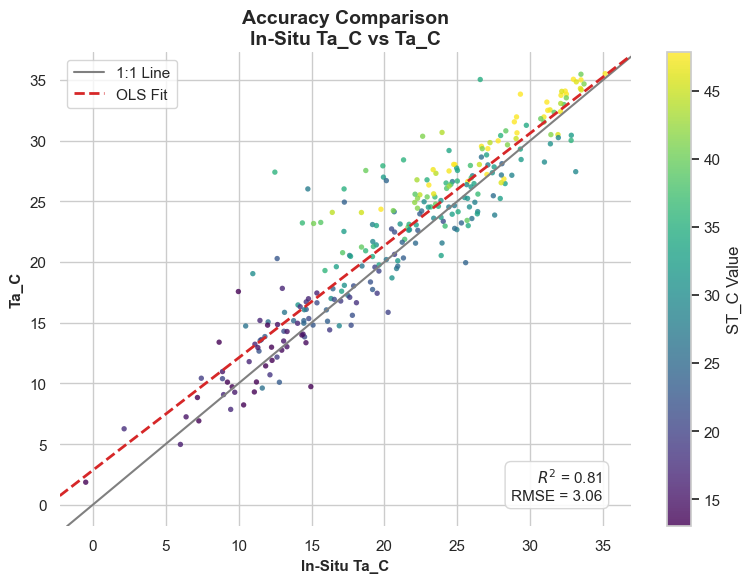

In [8]:
plot_insitu_accuracy(processed_df, variable_name="Ta_C", color="ST_C")

Relative Humidity Accuracy

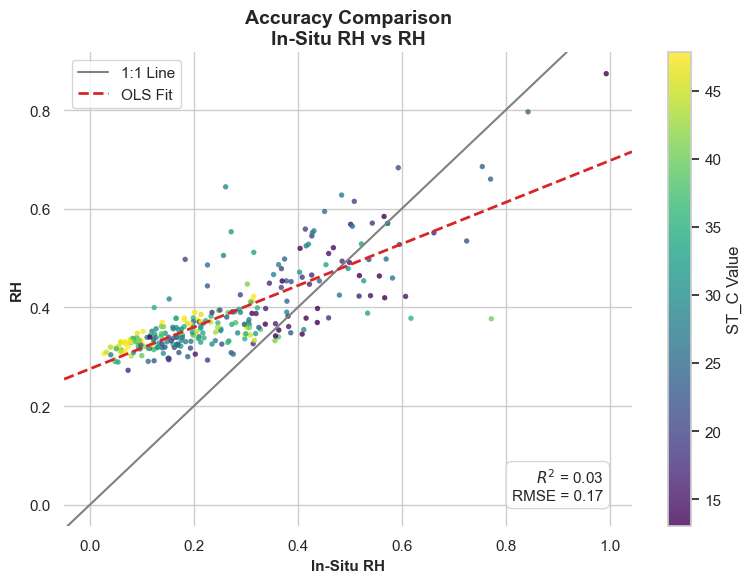

In [9]:
plot_insitu_accuracy(processed_df, variable_name="RH", color="ST_C")

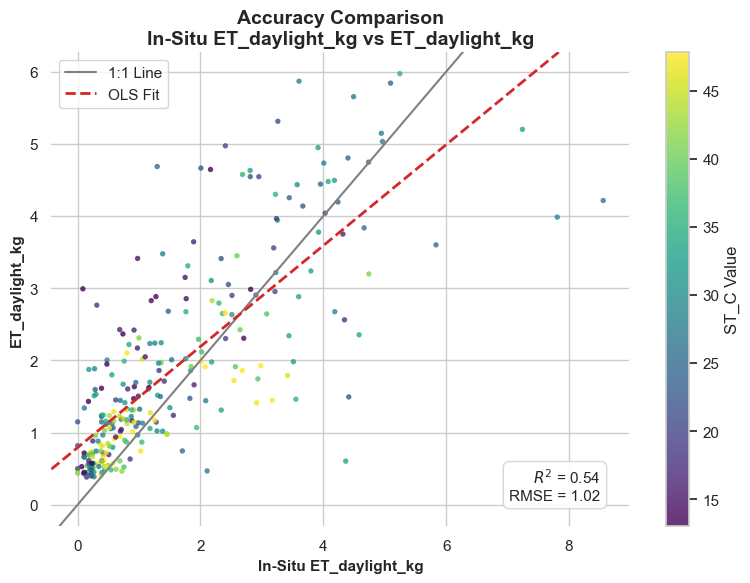

In [10]:
plot_insitu_accuracy(processed_df, variable_name="ET_daylight_kg", color="ST_C")

Executing forward process for 6144 generated samples (console output hidden)...
Forward process complete.


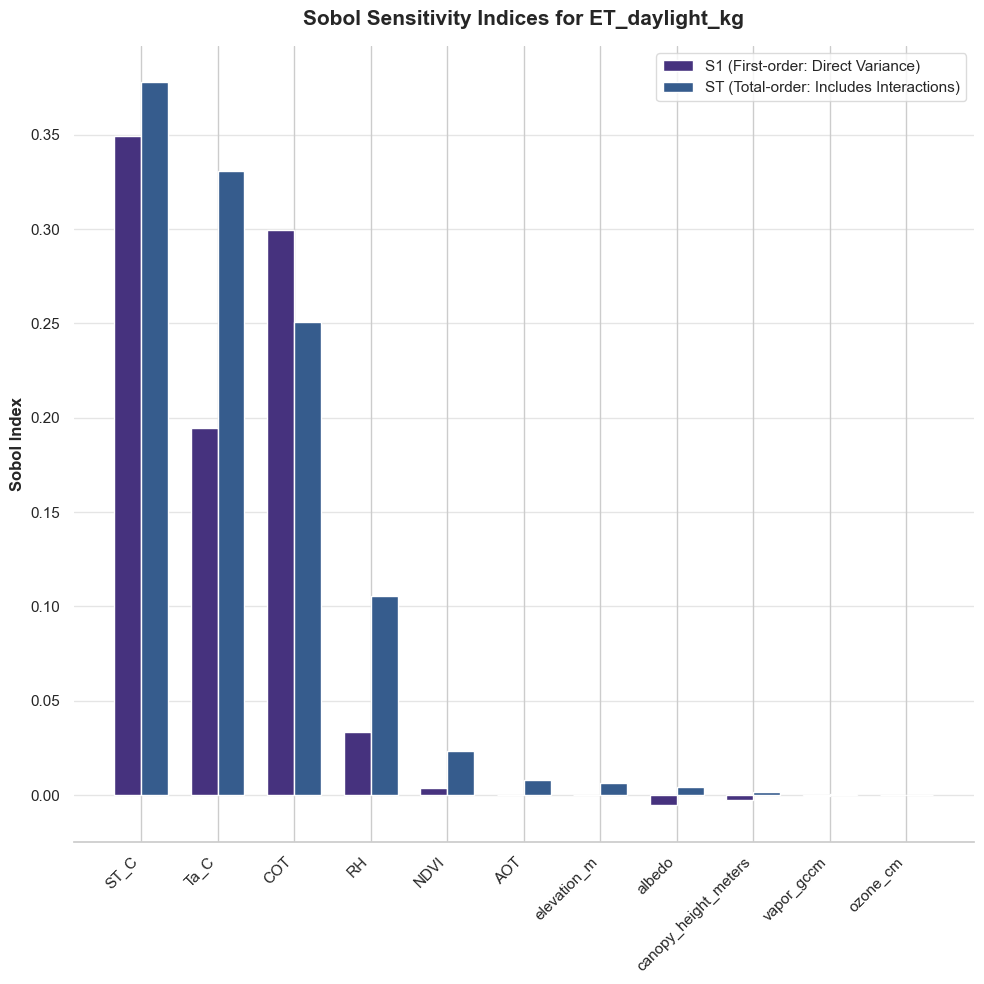

In [11]:
# Execute End-to-End GSA for ET_daylight_kg
target_output = "ET_daylight_kg"

input_variables = [
    "ST_C", "NDVI", "albedo", "Ta_C", "RH", 
    "AOT", "COT", "vapor_gccm", "ozone_cm", 
    "elevation_m", "canopy_height_meters"
]

Si_results = SOBOL_sensitivity_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
    # palette_name="viridis"
)

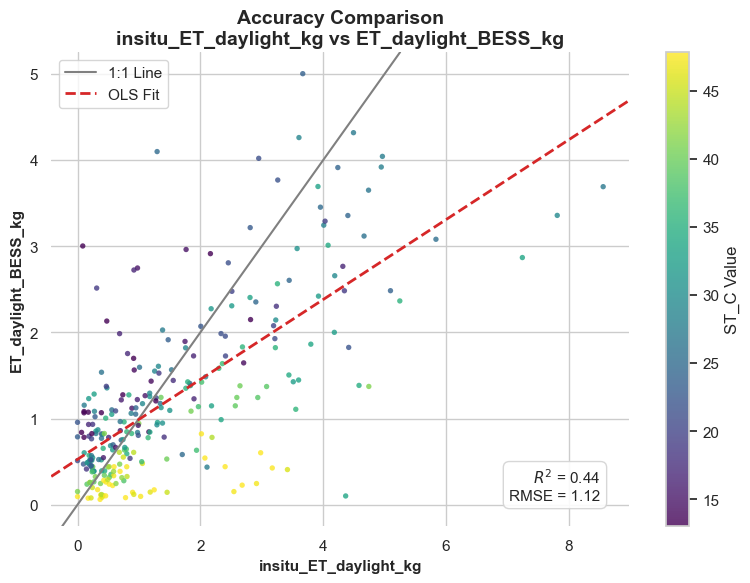

In [12]:
plot_insitu_accuracy(processed_df, variable_name="ET_daylight_BESS_kg", insitu_variable_name="insitu_ET_daylight_kg", color="ST_C")

/var/folders/bv/410kt7f93x78j9dww00h1pz80000gn/T/ipykernel_16503/1295787759.py:31: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 6144 generated samples (console output hidden)...
Forward process complete.


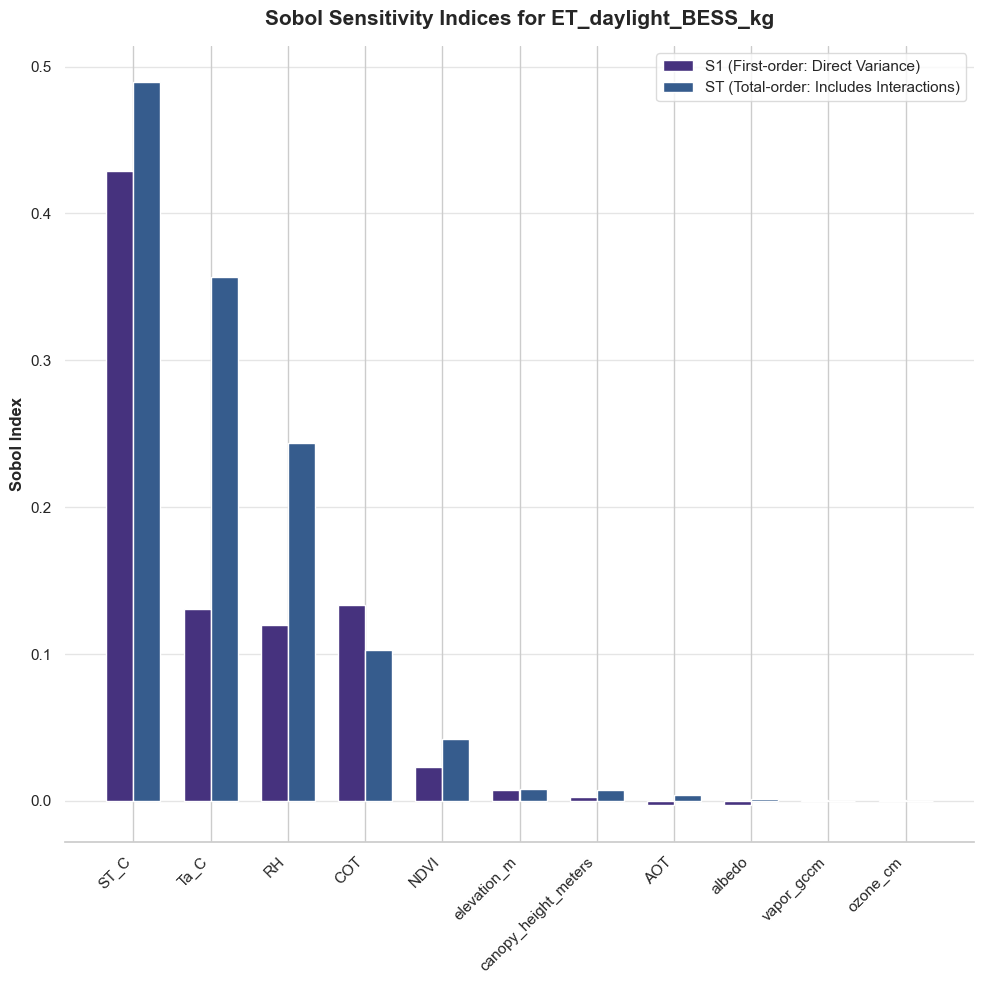

In [13]:
# Execute End-to-End GSA for ET_daylight_kg
target_output = "ET_daylight_BESS_kg"

input_variables = [
    "ST_C", "NDVI", "albedo", "Ta_C", "RH", 
    "AOT", "COT", "vapor_gccm", "ozone_cm", 
    "elevation_m", "canopy_height_meters"
]

Si_results = SOBOL_sensitivity_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)

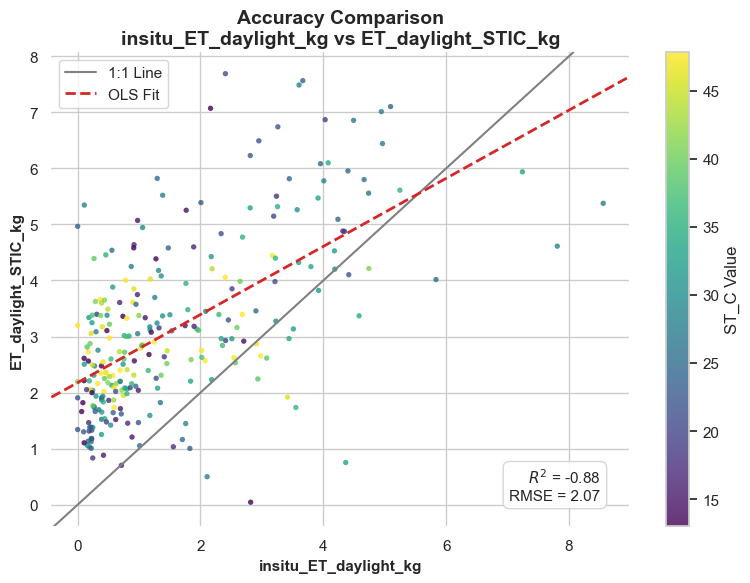

In [14]:
plot_insitu_accuracy(processed_df, variable_name="ET_daylight_STIC_kg", insitu_variable_name="insitu_ET_daylight_kg", color="ST_C")

/var/folders/bv/410kt7f93x78j9dww00h1pz80000gn/T/ipykernel_16503/1295787759.py:31: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 6144 generated samples (console output hidden)...
Forward process complete.


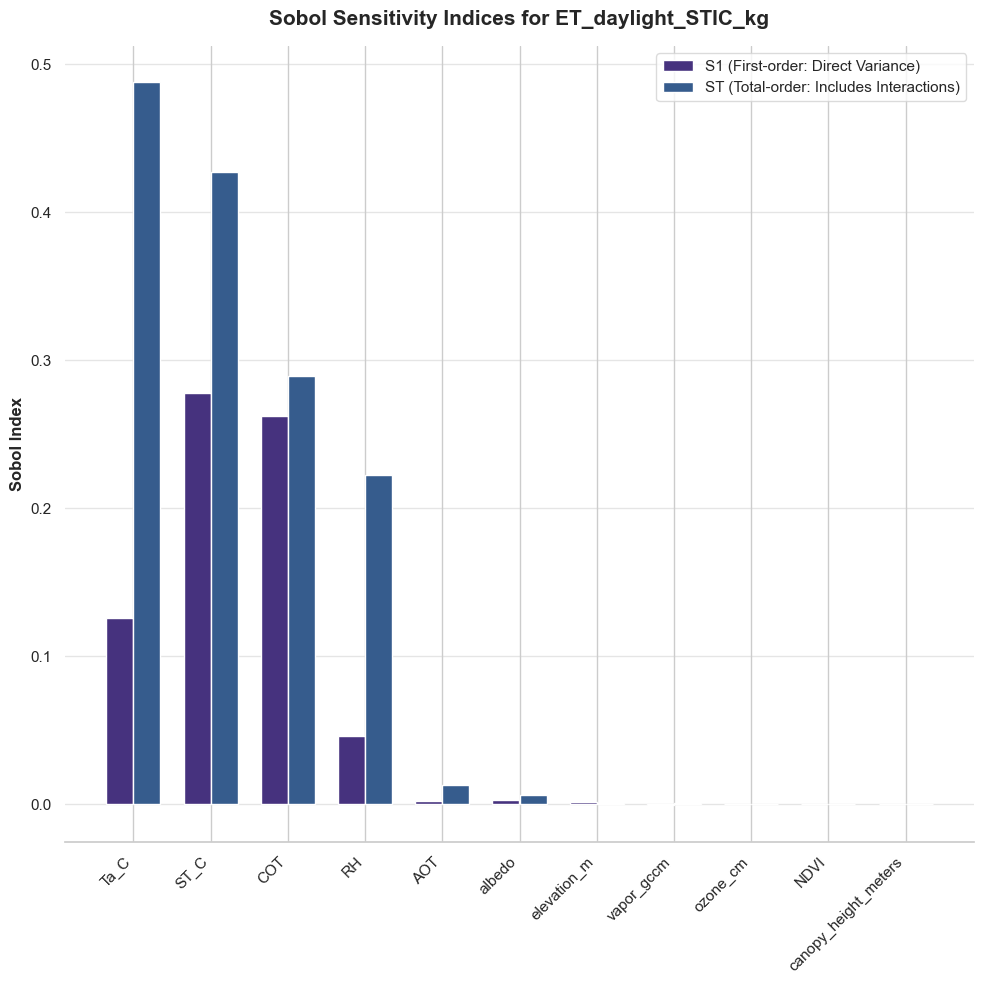

In [15]:
# Execute End-to-End GSA for ET_daylight_kg
target_output = "ET_daylight_STIC_kg"

input_variables = [
    "ST_C", "NDVI", "albedo", "Ta_C", "RH", 
    "AOT", "COT", "vapor_gccm", "ozone_cm", 
    "elevation_m", "canopy_height_meters"
]

Si_results = SOBOL_sensitivity_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)

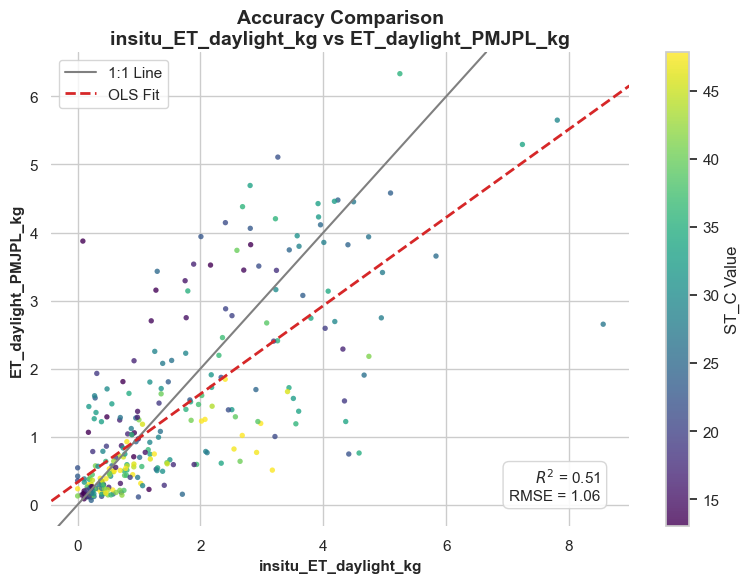

In [16]:
plot_insitu_accuracy(processed_df, variable_name="ET_daylight_PMJPL_kg", insitu_variable_name="insitu_ET_daylight_kg", color="ST_C")

/var/folders/bv/410kt7f93x78j9dww00h1pz80000gn/T/ipykernel_16503/1295787759.py:31: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 6144 generated samples (console output hidden)...
Forward process complete.


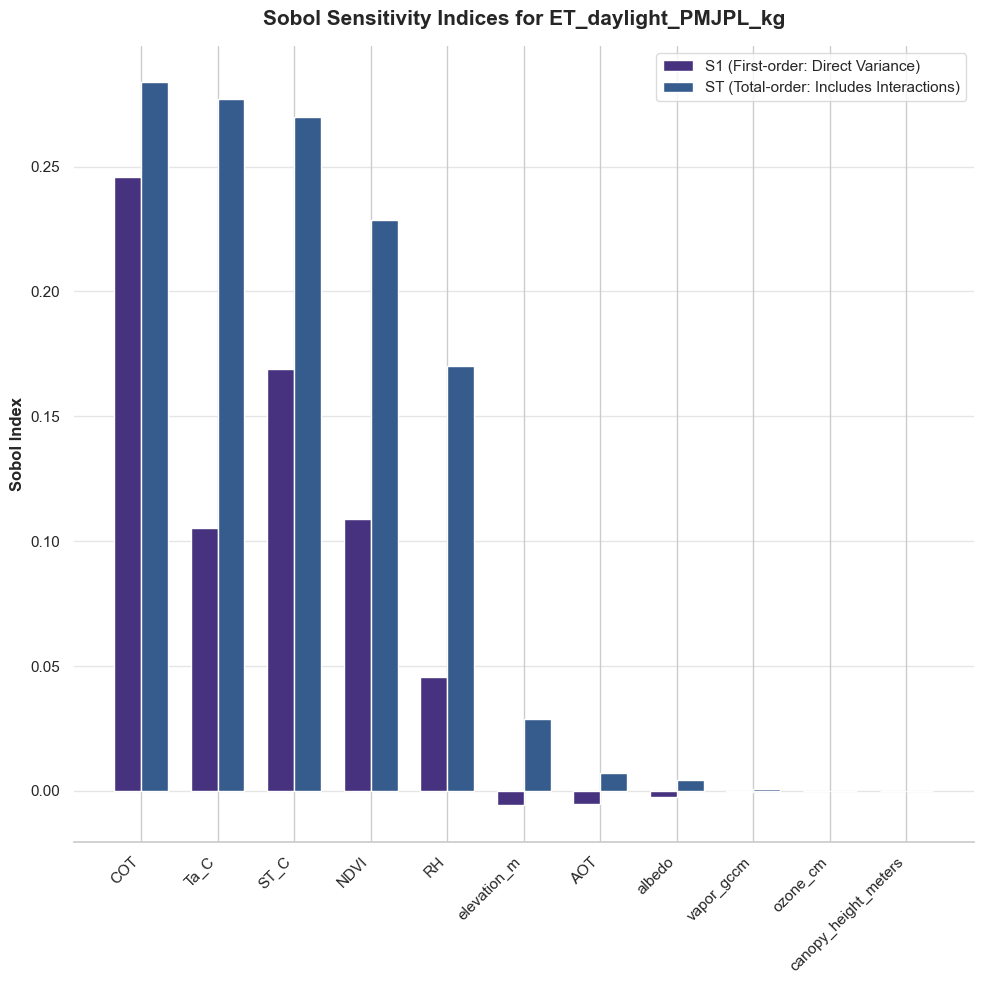

In [17]:
# Execute End-to-End GSA for ET_daylight_kg
target_output = "ET_daylight_PMJPL_kg"

input_variables = [
    "ST_C", "NDVI", "albedo", "Ta_C", "RH", 
    "AOT", "COT", "vapor_gccm", "ozone_cm", 
    "elevation_m", "canopy_height_meters"
]

Si_results = SOBOL_sensitivity_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)

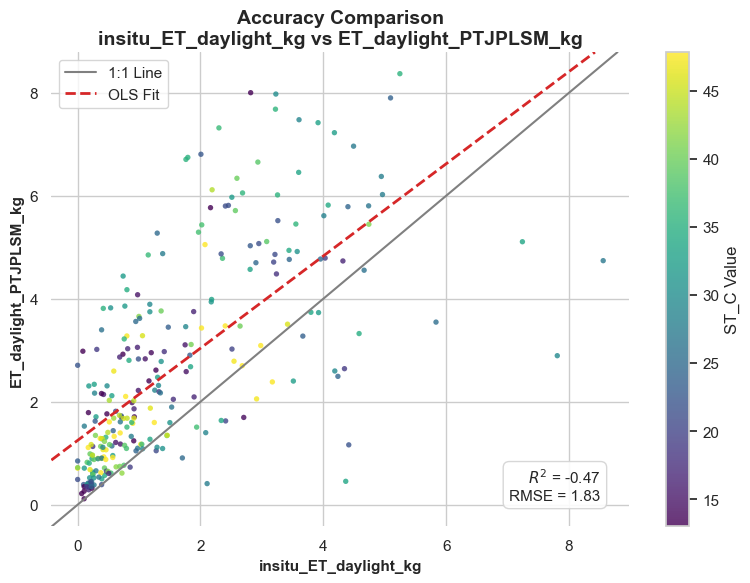

In [18]:
plot_insitu_accuracy(processed_df, variable_name="ET_daylight_PTJPLSM_kg", insitu_variable_name="insitu_ET_daylight_kg", color="ST_C")

/var/folders/bv/410kt7f93x78j9dww00h1pz80000gn/T/ipykernel_16503/1295787759.py:31: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Executing forward process for 6144 generated samples (console output hidden)...
Forward process complete.


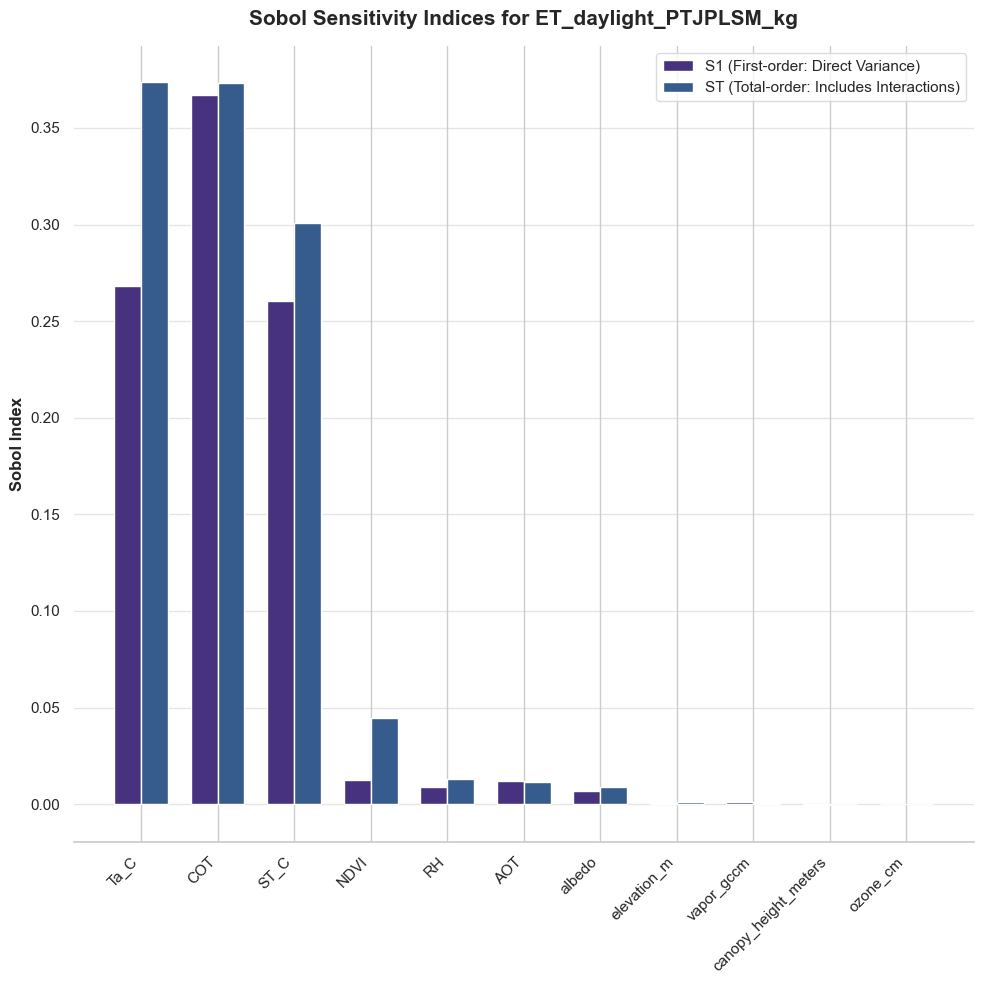

In [19]:
# Execute End-to-End GSA for ET_daylight_kg
target_output = "ET_daylight_PTJPLSM_kg"

input_variables = [
    "ST_C", "NDVI", "albedo", "Ta_C", "RH", 
    "AOT", "COT", "vapor_gccm", "ozone_cm", 
    "elevation_m", "canopy_height_meters"
]

Si_results = SOBOL_sensitivity_analysis(
    input_df=input_df, 
    input_variables=input_variables, 
    target_output=target_output,
    forward_process=process_JET_table,
    N=256,
)